## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub
from pathlib import Path
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_path = Path(path) / 'creditcard.csv'
df = pd.read_csv(csv_path)

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Data preparation and cleaning

In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [6]:
df.shape

(284807, 31)

#### Duplicates

In [7]:
df.duplicated().sum()

np.int64(1081)

In [8]:
df[df.duplicated()].Class.sum()/df.Class.sum()*100

np.float64(3.861788617886179)

In [9]:
# Data cleaned: without nulls and duplicates
df_cleaned = df.drop_duplicates()
print(df_cleaned.shape)
print(284807 - 283726)

(283726, 31)
1081


## 3. Exploratory data analysis

### 3.1 Target distribution

#### after duplicates droped

In [10]:
df_cleaned.Class.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [11]:
print(f"{(df_cleaned.Class.sum()/df_cleaned.shape[0])*100}%")

0.1667101358352777%


### 3.2 Amount and time

#### Amount

min: 0.0
max: 25691.16
mean: 88.47268731099723


<Axes: xlabel='Amount', ylabel='Count'>

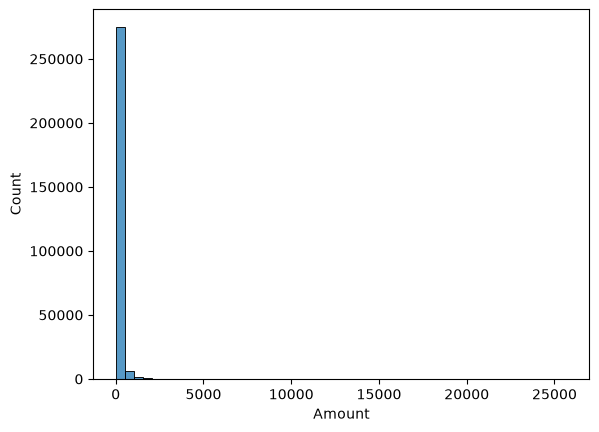

In [12]:
print('min:',df_cleaned['Amount'].min())

print('max:',df_cleaned['Amount'].max())

print('mean:', df_cleaned['Amount'].mean())

sns.histplot(df_cleaned['Amount'], bins = 50)

In [13]:
print("transaction with amount = 0:", df_cleaned[df_cleaned.Amount==0].shape[0])
print("transaction with amount = 0 and that are fraud:",df_cleaned[(df_cleaned.Amount==0) & (df_cleaned.Class == 1)].shape[0])
print(f'relation between all the transactions with amount = 0 and amount = 0 and that are fraud:',
      f'{df_cleaned[(df_cleaned.Amount==0) & (df_cleaned.Class == 1)].shape[0]/df_cleaned[df_cleaned.Amount==0].shape[0]*100}%')

transaction with amount = 0: 1808
transaction with amount = 0 and that are fraud: 25
relation between all the transactions with amount = 0 and amount = 0 and that are fraud: 1.3827433628318584%


In [14]:
df_cleaned['Amount'].value_counts()

Amount
1.00      13566
1.98       6044
0.89       4871
9.99       4738
15.00      3280
          ...  
787.95        1
405.09        1
381.05        1
337.54        1
95.63         1
Name: count, Length: 32767, dtype: int64

In [15]:
df_cleaned[df_cleaned.Amount<1].shape

(16765, 31)

In [16]:
df_cleaned[(df_cleaned.Amount==0) & (df_cleaned.Class == 1)].shape[0]/df_cleaned[df_cleaned.Amount==0].shape[0]*100

1.3827433628318584

In [17]:
df_cleaned['cero_transaction'] = df_cleaned.Amount==0
df_cleaned.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,cero_transaction
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,False
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,False
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,False
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,False
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,False


**note**: so here I am seeing that there are a huge amount of transactions with a low value. And for all the transactions that have an amount of 0 and are fraud are 1.38% of all the transactions that have an amount of 0, which compared to a 0.167% that is the relationship between all the fraud transactions and the total of transactions is roughly 8x higher. So I'm partitioning the DF to see what is the relationship between a low amoutn transaction and fraud.

In [18]:
limits = [0,1,2,5,10,20,50,100, 1000, np.inf]
labels = ['0-1', '1-2', '2-5', '5-10', '10-20', '20-50', '50-100', '100-1000', '1000-max']
df_cuted = pd.cut(df_cleaned['Amount'], bins = limits, labels = labels, include_lowest=True)
df_cuted.head()

0    100-1000
1         2-5
2    100-1000
3    100-1000
4      50-100
Name: Amount, dtype: category
Categories (9, str): ['0-1' < '1-2' < '2-5' < '5-10' ... '20-50' < '50-100' < '100-1000' < '1000-max']

In [19]:
fraud_relation = df_cleaned.Class.groupby(df_cuted).mean()*100
fraud_relation

Amount
0-1         0.563780
1-2         0.096883
2-5         0.110211
5-10        0.086889
10-20       0.056895
20-50       0.063880
50-100      0.147933
100-1000    0.216968
1000-max    0.306644
Name: Class, dtype: float64

**note:** here we can se that a 0.56% of the transactions that logged a transaction with a value between 0 and 1 are fraud. The same reading applies to the other bins.

In [20]:
list(df_cuted.unique().sort_values())

['0-1',
 '1-2',
 '2-5',
 '5-10',
 '10-20',
 '20-50',
 '50-100',
 '100-1000',
 '1000-max']

In [21]:
fig = px.bar(y=fraud_relation, x=df_cuted.unique().sort_values())
fig.show()


#### Time

In [22]:
print('min:',df_cleaned['Time'].min())

print('max:',df_cleaned['Time'].max())

print('mean:', df_cleaned['Time'].mean())

min: 0.0
max: 172792.0
mean: 94811.07759951502


In [23]:
df_cleaned['day'] = (df_cleaned['Time']/(3600))//24
df_cleaned['hour'] = (df_cleaned['Time']//(3600))%24 

df_cleaned[['Time', 'day', 'hour']].sample(10)

,Time,day,hour
173626,121572.0,1.0,9.0
189057,128247.0,1.0,11.0
7082,9281.0,0.0,2.0
275171,166406.0,1.0,22.0
101180,67748.0,0.0,18.0
69315,53364.0,0.0,14.0
204796,135454.0,1.0,13.0
184905,126440.0,1.0,11.0
94694,64990.0,0.0,18.0
2139,1646.0,0.0,0.0


In [24]:
df_analysis = pd.concat([df_cleaned['Class'].groupby(df_cleaned.hour).agg(['count', 'sum']), 
           df_cleaned['Class'].groupby(df_cleaned.hour).mean().sort_values(ascending=False)*100],
           axis = 1)

df_analysis

,count,sum,Class
hour,,,
0.0,7647,6,0.078462
1.0,4208,10,0.237643
2.0,3308,48,1.451028
3.0,3487,17,0.487525
4.0,2204,23,1.043557
5.0,2988,11,0.368139
6.0,4082,9,0.220480
7.0,7233,23,0.317987
8.0,10232,9,0.087959


**note:** Here we can see different relations: 
- here we see that at the hours 2, 4 the fraud transactions overpass 1%. this reading can be made with the other ours. Comparing this with the 0.167% of fraud transaction in all the dataframe we can infer that this hours contains the most percentage of this anomalies. We can compare these values with the overall precentage of fraud transactions on the dataframe (0.167%) which give us that the hour to has 8.7 times this value.
- Also we can see that although the hour 2 has the biggest percentage of fraud transaction, is not the onw that has most frauds transactions. Based on this we can infere that hour 2 is the hour with the biggest probability to have fraud transactions and hour 11 is the hour were most fraud transactions occur.
<!-- - We can also observe that a block of hours from the 1st hour to the 7th hour have the biggest rates of fraud transactions. This block also counts with a small number of records (e.g 1st hour with 4208, 5th hour with 2988, 7th hour with 7233) against the 10th, 11th, 12th hours that have 16548, 16781, 15378 respectively. Based on this behavior we can infer that these hours could represent night hours.    -->

### 3.3 Feature correlation

<Axes: >

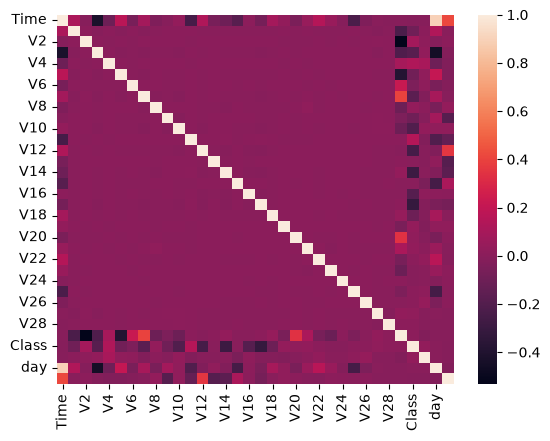

In [25]:
correlations = df_cleaned.corr()
sns.heatmap(correlations)

In [26]:
df_cleaned.corrwith(df_cleaned.Class).sort_values()

V17                -0.313498
V14                -0.293375
V12                -0.250711
V10                -0.206971
V16                -0.187186
V3                 -0.182322
V7                 -0.172347
V18                -0.105340
V1                 -0.094486
V9                 -0.094021
V5                 -0.087812
V6                 -0.043915
hour               -0.016740
Time               -0.012359
V24                -0.007210
V23                -0.006333
day                -0.005451
V13                -0.003897
V15                -0.003300
V25                 0.003202
V26                 0.004265
V22                 0.004887
Amount              0.005777
V28                 0.009682
V20                 0.021486
V27                 0.021892
cero_transaction    0.023871
V21                 0.026357
V8                  0.033068
V19                 0.033631
V2                  0.084624
V4                  0.129326
V11                 0.149067
Class               1.000000
dtype: float64

here we can see that there is no a big correlation overall which we can assume is because of the imbalanced proportion of the dataframe target. We observe that the features with the largest correlation are  V17, V14 , V12 , V10, V16, V3, V7, V18 with a negative correlation which means that in a fraud transactions this features tend to decrease and V4, V11 with a positive correlation. Additionally, we see that amount has a nearly 0 correlation with the target class, this is likely because Pearson only measures linear relations and this relation has a U form. However we already saw that low value transactions have an important relation with fraud. With all of these we can say that if the relations are not linear, tree models have advantage over logistic regression.

## 4. Train/Validation/Test split

In [27]:
df_cleaned.shape

(283726, 34)

In [28]:
y_cleaned = df_cleaned['Class']
del df_cleaned['Class']

In [29]:
from sklearn.model_selection import train_test_split

X_full_train, X_test, y_full_train, y_test = train_test_split(df_cleaned, y_cleaned, test_size = 0.2, shuffle = True, stratify=y_cleaned, random_state=42)

print(X_full_train.shape)
print(y_full_train.shape)
print(X_test.shape)
print(y_test.shape)

(226980, 33)
(226980,)
(56746, 33)
(56746,)


## 5. Model Selection

### 5.1 Baseline

In [35]:
pred_ones = np.ones(y_full_train.shape[0])

print((pred_ones == y_full_train).mean())

pred_zeros = np.zeros(y_full_train.shape[0])

print((pred_zeros == y_full_train).mean())

0.0016653449643140364
0.998334655035686


### 5.2 Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

lr = LogisticRegression(random_state = 42)

skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

auc_lr=[]
avg_pr_lr = []

for idx_train, idx_val in skf.split(X_full_train,y_full_train):
    X_train = X_full_train.iloc[idx_train]
    y_train = y_full_train.iloc[idx_train]

    X_train = scaler.fit_transform(X_train)

    X_val = scaler.transform(X_full_train.iloc[idx_val])
    y_val = y_full_train.iloc[idx_val]

    model = lr.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:,1]
    
    auc = roc_auc_score(y_val, y_pred)
    auc_lr.append(auc)

    avg_pr = average_precision_score(y_val, y_pred)
    avg_pr_lr.append(avg_pr)
    
    print(f'auc: {auc}')
    print(f'avg precision: {avg_pr}')
    

auc: 0.9770146289799431
avg precision: 0.7496896294100115
auc: 0.9623912387929069
avg precision: 0.744489588900016
auc: 0.9639650206717146
avg precision: 0.7096475404195143
auc: 0.9909622218609188
avg precision: 0.7707500123981955
auc: 0.9959100780415293
avg precision: 0.8080603221609078


### 5.3 Decision Tree

In [34]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

scaler = StandardScaler()

auc_dt=[]
avg_pr_dt=[]

for idx_train, idx_val in skf.split(X_full_train,y_full_train):
    X_train = X_full_train.iloc[idx_train]
    y_train = y_full_train.iloc[idx_train]

    X_train = scaler.fit_transform(X_train)

    X_val = scaler.transform(X_full_train.iloc[idx_val])
    y_val = y_full_train.iloc[idx_val]

    model = dt.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:,1]

    auc = roc_auc_score(y_val, y_pred)
    auc_dt.append(auc)

    avg_pr = average_precision_score(y_val, y_pred)
    avg_pr_dt.append(avg_pr)
    
    print(f'auc: {auc}')
    print(f'avg precision: {avg_pr}')

auc: 0.8398786434544694
avg precision: 0.5598835196507296
auc: 0.8598014165618586
avg precision: 0.5404625958234206
auc: 0.8616324847865472
avg precision: 0.5383359955389255
auc: 0.9208099131323454
avg precision: 0.6269473270066337
auc: 0.8945382542853161
avg precision: 0.607639903353414


### 5.4 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print('end')

rf = RandomForestClassifier(random_state=42)

skf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

scaler = StandardScaler()

auc_rf=[]
avg_pr_rf=[]

for idx_train, idx_val in skf.split(X_full_train,y_full_train):
    
    X_train = X_full_train.iloc[idx_train]
    y_train = y_full_train.iloc[idx_train]

    X_train = scaler.fit_transform(X_train)

    X_val = scaler.transform(X_full_train.iloc[idx_val])
    y_val = y_full_train.iloc[idx_val]

    model = rf.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:,1]
    
    auc = roc_auc_score(y_val, y_pred)
    auc_rf.append(auc)

    avg_pr = average_precision_score(y_val, y_pred)
    avg_pr_rf.append(avg_pr)
    
    print(f'auc: {auc}')
    print(f'avg precision: {avg_pr}')



end
auc: 0.9313389672190228
avg precision: 0.8233528548391778
auc: 0.9518685230540663
avg precision: 0.8632856536627493
auc: 0.9058089840665212
avg precision: 0.7767222823615818
auc: 0.9527311631904121
avg precision: 0.8633392223020279
auc: 0.9654663329771914
avg precision: 0.8585145026586812


### 5.5 XGBoost

In [36]:
from xgboost import XGBClassifier

xgbc = XGBClassifier(random_state = 42)

scaler = StandardScaler()

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

auc_xgb = []
avg_pr_xgb = []

for train_idx, val_idx in skf.split(X_full_train, y_full_train):
    X_train = X_full_train.iloc[train_idx]
    y_train = y_full_train.iloc[train_idx]

    X_train = scaler.fit_transform(X_train)

    X_val = scaler.transform(X_full_train.iloc[val_idx])
    y_val = y_full_train.iloc[val_idx]

    model = xgbc.fit(X_train, y_train)

    y_pred = model.predict_proba(X_val)[:,1]

    auc = roc_auc_score(y_val, y_pred)
    auc_xgb.append(auc)

    avg_pr = average_precision_score(y_val, y_pred)
    avg_pr_xgb.append(avg_pr)

    print(f'auc: {auc}')
    print(f'avg precision: {avg_pr}')


auc: 0.9067072659473534
avg precision: 0.7780448857392317
auc: 0.916944757029486
avg precision: 0.8123503841679607
auc: 0.9249729990244809
avg precision: 0.7412400325676279
auc: 0.9633242555860082
avg precision: 0.8252753447805543
auc: 0.9617333755284062
avg precision: 0.8561457778213029


### 5.6 model comparison

In [44]:
print('============================AUC=====================================')
print('Logistic regression')
print(f'average auc: {np.mean(auc_lr)}  |  std auc: {np.std(auc_lr)}')
print('Decision Tree')
print(f'average auc: {np.mean(auc_dt)}  |  std auc: {np.std(auc_dt)}')
print('Random Forest')
print(f'average auc: {np.mean(auc_rf)}  |  std auc: {np.std(auc_rf)}')
print('XGboost')
print(f'average auc: {np.mean(auc_xgb)}  |  std auc: {np.std(auc_xgb)}')


print('===============================AVG PRECISION==================================')
print('Logistic regression')
print(f'average precision: {np.mean(avg_pr_lr)}  |  std precision: {np.std(avg_pr_lr)}')
print('Decision Tree')
print(f'average precision: {np.mean(avg_pr_dt)}  |  std precision: {np.std(avg_pr_dt)}')
print('Random Forest')
print(f'average precision: {np.mean(avg_pr_rf)}  |  std precision: {np.std(avg_pr_rf)}')
print('XGboost')
print(f'average precision: {np.mean(avg_pr_xgb)}  |  std precision: {np.std(avg_pr_xgb)}')

============================AUC=====================================
Logistic regression
average auc: 0.9780486376694025  |  std auc: 0.013640845209322964
Decision Tree
average auc: 0.8753321424441074  |  std auc: 0.02871562994538389
Random Forest
average auc: 0.9414427941014429  |  std auc: 0.020905067597459553
XGboost
average auc: 0.934736530623147  |  std auc: 0.02342477785825408
===============================AVG PRECISION==================================
Logistic regression
average precision: 0.756527418657729  |  std precision: 0.032395400929378905
Decision Tree
average precision: 0.5746538682746247  |  std precision: 0.03613551861181947
Random Forest
average precision: 0.8370429031648434  |  std precision: 0.033666608548927855
XGboost
average precision: 0.8026112850153355  |  std precision: 0.03960906506781358


**Conclusions:** 
- Based on these results we can observe that the average AUC ROC from lower to bigger is Decision Tree with (0.875 +/- 0.0287), XGBoost (0.935 +/- 0.0234), Random Forest (0.941 +/- 0.0209) and Logistic Regression (0.978 +/- 0.0136) the largest AUC ROC score. Also, we can infer that the ROC AUC metric is large for all of the models because of the rate of true negatives (FPR: FP/(FP+TN)) which results in a lower FPR because of the imbalance on the target class in the dataframe, which represents a 0.167%.

- On the precision side, metric that summarizes the precision-recall curve score over the thresholds, we observe that meanwhile the baseline resulted in precision score of 0.00167, which is a low metric, the Logistic Regression is the 3rd place in this ranking, with a score of 0.757 +/- 0.0323, which could be caused by the non-linear relationship between the variables/features of the dataframe with the target. Another possible cause is that during the training the model prompted a convergence warning, which means that the model couldn't be totally optimized.

- Regarding the Decision Tree, we see that it has the lowest mean precision score, this is 0.575 +/- 0.0361, which it's likely because the trees have no max depth parameter set, prompting that the leaves get pure, so the predicted probability is 1 or 0, resulting in a coarse ranking.

- Then, we see that Random Forest model had the largest mean precision score, this is 0.837 +/- 0.0337, which indicates that the ensemble of trees understood better the patterns than the other models, and successfully distinguished between fraud transactions and normal transactions.

- Next, we observe that the XGB model got a mean precision score of 0.803 +/- 0.0396, getting it the second place in the ranking, which means that this model also could distinguish between fraud transactions and normal transactions.

- Finally, we can see that random forest and xgb models are not so far from each other, their limits are 0.803, 0.871 for random forest, and 0.763, 0.843 for XGB. With this recognized we conclude that both models have a great performance in this task, so we are going to fine tune the two models.  

## 6. Hyperparameter tuning

### 6.1 Random Forest

#### 6.1.1 n_estimators

In [45]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score


num_estimators = [10,25,50,100,200]

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state=42)
scaler = StandardScaler()

scores = {}

for n in num_estimators:
    rf = RandomForestClassifier(n_estimators=n, random_state = 42, n_jobs=-1)

    score = []
    i=0
    for idx_train, idx_val in skf.split(X_full_train, y_full_train):

        X_train = scaler.fit_transform(X_full_train.iloc[idx_train])
        y_train = y_full_train.iloc[idx_train]

        X_val = scaler.transform(X_full_train.iloc[idx_val])
        y_val = y_full_train.iloc[idx_val]

        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:,1]
        pr = average_precision_score(y_val, y_pred)
        score.append(pr)
        print(f'{n}: {i} -> {pr}')

    scores[n] = (np.mean(score), np.std(score))



10: 0 -> 0.7727091329375854
10: 0 -> 0.8387838371310972
10: 0 -> 0.7495239372147113
10: 0 -> 0.8553228449091735
10: 0 -> 0.8316976045593197
25: 0 -> 0.7989729374066061
25: 0 -> 0.8576981788367284
25: 0 -> 0.7730865115853077
25: 0 -> 0.8612276002558147
25: 0 -> 0.8373443641782577
50: 0 -> 0.8180836952693513
50: 0 -> 0.8600966244942275
50: 0 -> 0.7748176440222146
50: 0 -> 0.8673354542231765
50: 0 -> 0.844927315941545
100: 0 -> 0.8233528548391778
100: 0 -> 0.8632856536627493
100: 0 -> 0.7767222823615818
100: 0 -> 0.8633392223020279
100: 0 -> 0.8585145026586812
200: 0 -> 0.8258710729822254
200: 0 -> 0.8628748251510147
200: 0 -> 0.779540529821965
200: 0 -> 0.870194906384088
200: 0 -> 0.8555056677546433


In [49]:
df_scores = pd.DataFrame(scores.values(), columns = ['mean', 'std'], index = scores.keys())
df_scores

,mean,std
10,0.809607,0.040989
25,0.825666,0.034363
50,0.833052,0.033654
100,0.837043,0.033667
200,0.838797,0.033236


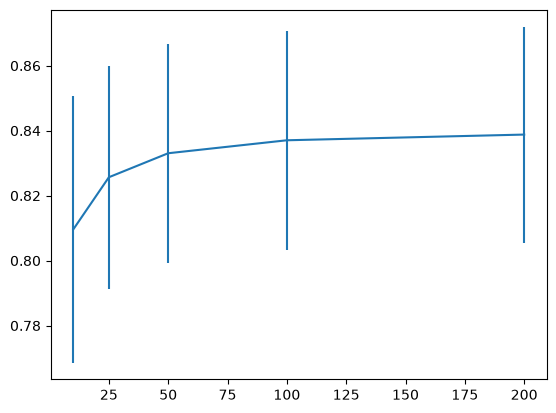

In [47]:
plt.errorbar(df_scores.index, df_scores['mean'], yerr=df_scores['std'])
plt.show()

**note:** Here we can see that the increment in the score is not significant across number of estimators. We can observe that with 10 estimators the average precision is 0.809+/-0.041, and with 200 estimators the average precision score is 0.839+/-0.033, which is a really close score difference. We see that the total gain from 10 estimators to 200 estimators is 0.029 and its deviation between folds is 0.033, so the gain is less than the deviation, which can be interpreted as noise. Also, we notice that the performance score has diminishing returns (+0.016, +0.007, 0.004, 0.002) which leads to the asymptotic curve we see in the previous graphic.
With this we can infer that this parameter won't affect significantly the performance of the model, so we are going to continue with 100 n_estimators, so we can have a model with a good performance without increasing computational cost.

#### 6.1.2 max_depth

In [66]:
depths = [tree.get_depth() for tree in rf.estimators_]
print(f'Depths: {np.max(depths)} - {np.min(depths)}')

Depths: 33 - 15


In [67]:
n_depth = [3,5,8,12,18,25,40]

scores = {}

for n in n_depth:
    rf = RandomForestClassifier(n_estimators = 100, max_depth=n, random_state = 42, n_jobs=-1)

    score = []
    for train_idx, val_idx in skf.split(X_full_train, y_full_train):
        X_train = scaler.fit_transform(X_full_train.iloc[train_idx])
        y_train = y_full_train.iloc[train_idx]

        X_val = scaler.transform(X_full_train.iloc[val_idx])
        y_val = y_full_train.iloc[val_idx]

        rf.fit(X_train, y_train)
        y_pred = rf.predict_proba(X_val)[:,1]

        pr = average_precision_score(y_val, y_pred)
        score.append(pr)
        print(f'{n}: {pr}')
    scores[n] = (np.mean(score), np.std(score))


3: 0.7742805571743637
3: 0.8015139589619391
3: 0.7021693789583386
3: 0.7911131968700671
3: 0.8112052311407538
5: 0.8017655757938159
5: 0.8379733598213961
5: 0.7501322540248275
5: 0.8390793155706249
5: 0.8252494723292878
8: 0.8233628047204303
8: 0.8553835036248681
8: 0.7726568338776939
8: 0.8599679366031158
8: 0.8610088311041162
12: 0.8275987570720862
12: 0.8625255019723015
12: 0.7790401909426482
12: 0.8697423715410579
12: 0.864986590866487
18: 0.8284662571886089
18: 0.8640163104675753
18: 0.7798547041103587
18: 0.8696654660960548
18: 0.8653052721195772
25: 0.8212483977190679
25: 0.8636816841411256
25: 0.7775653224524633
25: 0.861370468005915
25: 0.8625506603698327
40: 0.8233528548391778
40: 0.8632856536627493
40: 0.7767222823615818
40: 0.8633392223020279
40: 0.8585145026586812


In [69]:
df_scores

,mean,std
3,0.776056,0.038917
5,0.810840,0.033194
8,0.834476,0.033871
12,0.840779,0.034302
18,0.841462,0.034167
25,0.837283,0.033879
40,0.837043,0.033667


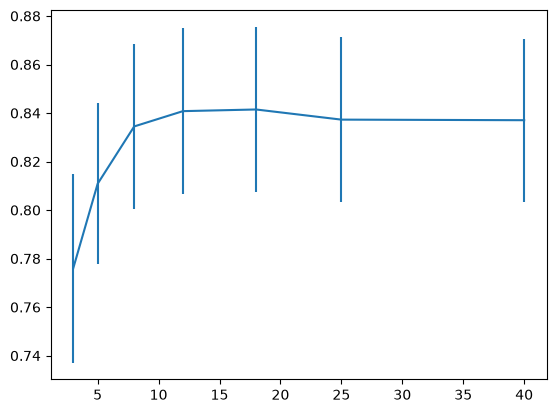

In [68]:
df_scores = pd.DataFrame(scores.values(), columns=['mean', 'std'], index = scores.keys())

plt.errorbar(df_scores.index, df_scores['mean'], yerr = df_scores['std'])
plt.show()

**note:** Here we see that the average precision significantly decreases when the max_depth parameter is less than 8. We see that from 3 to 12 the performance is improved by 0.065 which corresponds to ~2 deviations. Also, we see that when max_depth is equal to 40 the score is the same as no max_depth set, which confirms that the parameter stops improving the perfomance of the model when it is greater than 33. Finally, we can observe that in the range of 12 - 40 of max depth the difference between the maximum (0.841462) and minimum (0.837043) value is 0.0045 approximately, this difference is less than the deviation between folds (~0.034), which means that this range is indistiguishable. This way, we can choose 12 as max_depth which allows us to reduce the computational cost.

#### 6.1.3 min_samples_leaf

1 -> 0.8275987570720862
1 -> 0.8625255019723015
1 -> 0.7790401909426482
1 -> 0.8697423715410579
1 -> 0.864986590866487
2 -> 0.8209329753590441
2 -> 0.8607256095397616
2 -> 0.7807274562787972
2 -> 0.8809586805822917
2 -> 0.8497385278788976
3 -> 0.8183425697467118
3 -> 0.8548784386370297
3 -> 0.7703642029205932
3 -> 0.8614051296733267
3 -> 0.8593633862704435
5 -> 0.8176415008663908
5 -> 0.8549139679676034
5 -> 0.7693515311202845
5 -> 0.8532276216510916
5 -> 0.8500532989422568
7 -> 0.8103213205031959
7 -> 0.854201596756595
7 -> 0.7637321479800254
7 -> 0.864304093493415
7 -> 0.8548479463801277
10 -> 0.8108092071648678
10 -> 0.8466221755946334
10 -> 0.7592426499236924
10 -> 0.85915914401388
10 -> 0.8531249963825304


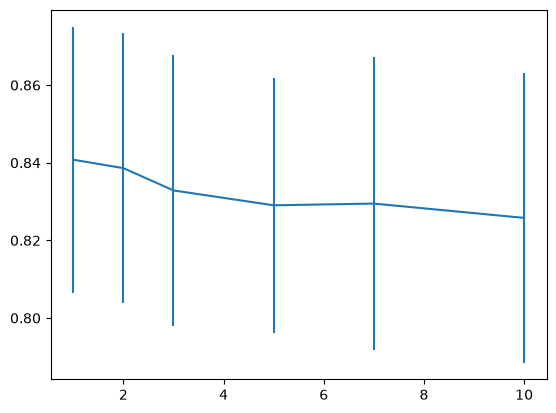

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

skf = StratifiedKFold(n_splits = 5, random_state = 42, shuffle=True)
scaler = StandardScaler()

min_samples_leaf = [1,2,3,5,7,10]
scores = {}
for n in min_samples_leaf:
    score = []
    rf = RandomForestClassifier(n_estimators = 100, max_depth = 12, min_samples_leaf=n ,random_state = 42, n_jobs=-1)

    for train_idx, val_idx in skf.split(X_full_train, y_full_train):
        X_train = scaler.fit_transform(X_full_train.iloc[train_idx])
        y_train = y_full_train.iloc[train_idx]

        X_val = scaler.transform(X_full_train.iloc[val_idx])
        y_val = y_full_train.iloc[val_idx]

        rf.fit(X_train, y_train)

        y_pred = rf.predict_proba(X_val)[:,1]

        pr = average_precision_score(y_val, y_pred)
        score.append(pr)
        print(f'{n} -> {pr}')
    scores[n] = (np.mean(score), np.std(score))

df_scores = pd.DataFrame(scores.values(), columns=['mean', 'std'], index = scores.keys())

plt.errorbar(df_scores.index, df_scores['mean'], yerr=df_scores['std'])
plt.show()


In [38]:
df_scores

,mean,std
1,0.840779,0.034302
2,0.838617,0.034840
3,0.832871,0.034982
5,0.829038,0.032829
7,0.829481,0.037834
10,0.825792,0.037276


In [39]:
df_scores['mean'].iloc[0] - df_scores['mean'].iloc[-1]

np.float64(0.014987047862995317)

**note:** Here we observe that the model performance decreases with the increment of the min_samples_leaf value. We see that the total decrement is 0.015, which is less than half of the standard deviation obtained (~0.035). Therefore, there is no individual comparison that is significant. However, 5 out of 6 steps lower the performance. A noisy behaviour would show random fluctuations, but the graph and measures show a decreasing tendency. This is likely to happen because of the prior set parameters which already limit the complexity of the model, so modifying the min_samples_leaf parameter won't add a useful regularization to the model, instead it causes a perfoamnce degradation. This is why we will keep going with min_samples_leaf = 1. 

#### 6.1.4 class_weight
**note:** Fraud transactions nature can degrade model performance by the imbalance (0.167% of positive cases vs 99.833% of negative cases). This is why there is another parameter that can help us with this. In the case of scikit-learn Random Forest is 'class_weight', which accepts 'balanced' or 'balanced_subsample'. Therefore, we are going to test how random forest is affected by setting the parameter to 'balanced_subsample'. This configuration will penalize errors on the minority class during training, so the model can't "ignore" the frauds to minimize the total error. Also, to clarify we are using balanced_subsample because this setting allows the calculation of weights for every tree instead of calculating the weight for all the trees once. This helps because each bootstrap sample is different from the previous one so fraud proportion may vary within trees.

In [43]:
rf = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=1, class_weight='balanced_subsample', n_jobs=-1, random_state = 42)

scores = []

for train_idx, val_idx in skf.split(X_full_train, y_full_train):
    X_train = scaler.fit_transform(X_full_train.iloc[train_idx])
    y_train = y_full_train.iloc[train_idx]

    X_val = scaler.transform(X_full_train.iloc[val_idx])
    y_val = y_full_train.iloc[val_idx]

    rf.fit(X_train, y_train)
    y_pred = rf.predict_proba(X_val)[:,1]

    pr = average_precision_score(y_val, y_pred)
    scores.append(pr)
    print(pr)

0.8268395929008943
0.8482220216040393
0.7619748660362641
0.8342462267823678
0.8303573083905315


In [45]:
round(np.mean(scores),4), round(np.std(scores), 4)

(np.float64(0.8203), np.float64(0.0301))

**note:** with this parameter configured we observe that the performance took the value of 0.8203+/-0.0301, meanwhile without it the model performance was 0.841+/-0.0343, which shows us a minimum degradation in the mean of the average precision score, which makes sense because AUPRC measures ranking quality, which class weighting does not improve, it shifts the decision boundary instead. As we don't see a significant change there is no reason for adding this new parameter into the model's configuration. 

### 6.2 XGBoost

#### 6.2.1 eta

0.8000670857045692
0.8624785669144657
0.7905837678411856
0.8219662669237893
0.8497396342000562
0.8358877761579923
0.8626775571842971
0.7964340222359633
0.8468092920858147
0.8574386516899194
0.8129605167863748
0.8396416692641616
0.8024868840907317
0.8585948864250799
0.8744596019545042
0.7780448857392317
0.8123503841679607
0.7412400325676279
0.8252753447805543
0.8561457778213029
0.7172001667544854
0.782062495050695
0.7318343571489058
0.7813859577801845
0.8054840830979942


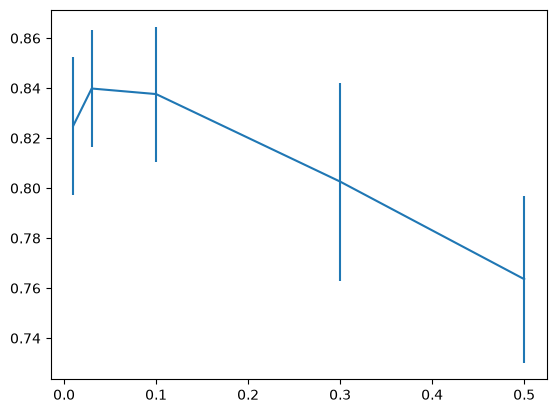

In [46]:
from xgboost import XGBClassifier

eta = [0.01, 0.03, 0.1,0.3, 0.5]

scores = {}
for n in eta:
    xgbc = XGBClassifier(eta=n, random_state = 42)
    score = []
    for train_idx, val_idx in skf.split(X_full_train, y_full_train):
        X_train = scaler.fit_transform(X_full_train.iloc[train_idx])
        y_train = y_full_train.iloc[train_idx]

        X_val = scaler.transform(X_full_train.iloc[val_idx])
        y_val = y_full_train.iloc[val_idx]

        xgbc.fit(X_train, y_train)

        y_pred = xgbc.predict_proba(X_val)[:,1]

        pr = average_precision_score(y_val, y_pred)
        score.append(pr)
        print(pr)
    scores[n] = (np.mean(score), np.std(score))

df_scores = pd.DataFrame(scores.values(), columns = ['mean', 'std'], index = scores.keys())

plt.errorbar(df_scores.index, df_scores['mean'], yerr=df_scores['std'])
plt.show()

In [47]:
df_scores

,mean,std
0.01,0.824967,0.027684
0.03,0.839849,0.023578
0.10,0.837629,0.026995
0.30,0.802611,0.039609
0.50,0.763593,0.033387


**note:** Here we observe that the model shows a slight improvement from 0.01 to 0.03 (0.840-0.825=0.015). Also, we see that after 0.03 the model performance tends to decrease, which tell us that with a bigger eta/learning rate the model degrades. Additionally, we see that from the default value (eta=0.3) to a 0.03 value the model presents an increment of 0.037 in the score, which is approximately 1.5 times the deviation. Therefore we got an improvement from the baseline and an equivalent performance compared with the random forest (0.841). Based on this, we'll continue using eta = 0.03 because it is the largest mean value (0.840) and a lower eta allows the model to generalize better.

#### 6.2.2 max_depth

2 -> 0.7910518403665205
2 -> 0.8539300959166944
2 -> 0.7721222217034727
2 -> 0.8045932466222491
2 -> 0.8547108017855185
3 -> 0.7984075432590673
3 -> 0.8548031972583938
3 -> 0.7819574585057973
3 -> 0.812336773702687
3 -> 0.8504349134220488
4 -> 0.8064079126753786
4 -> 0.859021867194454
4 -> 0.7906465295683104
4 -> 0.8289715829738916
4 -> 0.8517942733943559
6 -> 0.8358877761579923
6 -> 0.8626775571842971
6 -> 0.7964340222359633
6 -> 0.8468092920858147
6 -> 0.8574386516899194
8 -> 0.8372839865488562
8 -> 0.8650330537780221
8 -> 0.7929130568470025
8 -> 0.8652485107350806
8 -> 0.860866737674383
10 -> 0.8412135395572654
10 -> 0.8640540710764479
10 -> 0.795054073441482
10 -> 0.8568544143346102
10 -> 0.8539440963678128


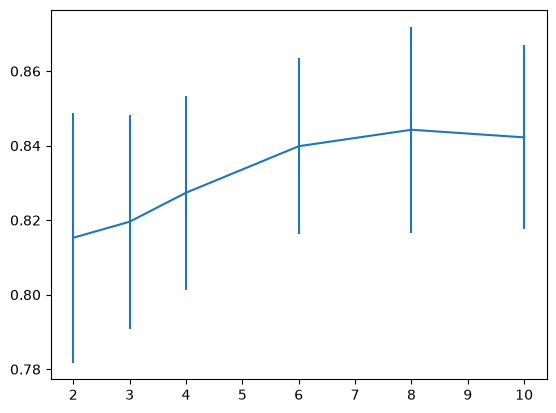

In [49]:
from xgboost import XGBClassifier

max_depth = [2,3,4,6,8,10]
scores = {}

for n in max_depth:
    xgbc = XGBClassifier(eta=0.03, max_depth = n, random_state = 42)
    score = []
    for train_idx, val_idx in skf.split(X_full_train, y_full_train):
        X_train = scaler.fit_transform(X_full_train.iloc[train_idx])
        y_train = y_full_train.iloc[train_idx]

        X_val = scaler.transform(X_full_train.iloc[val_idx])
        y_val = y_full_train.iloc[val_idx]

        xgbc.fit(X_train, y_train)

        y_pred = xgbc.predict_proba(X_val)[:,1]

        pr = average_precision_score(y_val, y_pred)
        score.append(pr)
        print(n, '->', pr)
    scores[n] = (np.mean(score), np.std(score))

df_scores = pd.DataFrame(scores.values(), columns = ['mean', 'std'], index = scores.keys())

plt.errorbar(df_scores.index, df_scores['mean'], yerr=df_scores['std'])
plt.show()

In [50]:
df_scores

,mean,std
2,0.815282,0.033503
3,0.819588,0.028667
4,0.827368,0.026034
6,0.839849,0.023578
8,0.844269,0.027688
10,0.842224,0.024714


**note:** Here we see that from a max_depth of 2 to 8 the performance tends to increase, the model performance increases 0.029 units. Then, when max_depth increases to 10 we see that the performance degrades slightly (0.002 units). We can say that from the default configuration (max_depth=6) to max_depth=8, is a very slight improvement which can be interpreted as noise. Therefore, we will continue the project with a limit depth equal to 6, choosing a simpler model with an already good performance.

#### 6.2.3 min_child_weight

1 -> 0.8358877761579923
1 -> 0.8626775571842971
1 -> 0.7964340222359633
1 -> 0.8468092920858147
1 -> 0.8574386516899194
3 -> 0.8439715099421605
3 -> 0.8619695976870811
3 -> 0.7877525280203495
3 -> 0.8504974032802834
3 -> 0.8555013607225328
5 -> 0.8321734915906278
5 -> 0.865408516259354
5 -> 0.7785601725760365
5 -> 0.8590981578019022
5 -> 0.8596183267924269
10 -> 0.830124251649401
10 -> 0.8647873954957334
10 -> 0.7756004937268423
10 -> 0.846265445063879
10 -> 0.8691605390757448
20 -> 0.8075066826128575
20 -> 0.8559990714935429
20 -> 0.7599434892993732
20 -> 0.8503385928639345
20 -> 0.8695858052511087


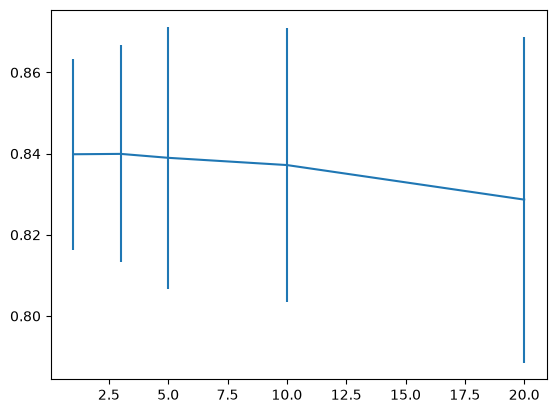

In [54]:
from xgboost import XGBClassifier

min_child_weight = [1,3,5,10,20]

scores = {}
for n in min_child_weight:
    xgbc = XGBClassifier(eta=0.03, max_depth=6, min_child_weight=n, random_state = 42)
    score = []
    for train_idx, val_idx in skf.split(X_full_train, y_full_train):
        X_train = scaler.fit_transform(X_full_train.iloc[train_idx])
        y_train = y_full_train.iloc[train_idx]

        X_val = scaler.transform(X_full_train.iloc[val_idx])
        y_val = y_full_train.iloc[val_idx]

        xgbc.fit(X_train, y_train)

        y_pred = xgbc.predict_proba(X_val)[:,1]

        pr = average_precision_score(y_val, y_pred)
        score.append(pr)
        print(n, '->', pr)
    scores[n] = (np.mean(score), np.std(score))

df_scores = pd.DataFrame(scores.values(), columns = ['mean', 'std'], index = scores.keys())

plt.errorbar(df_scores.index, df_scores['mean'], yerr=df_scores['std'])
plt.show()

In [55]:
df_scores

,mean,std
1,0.839849,0.023578
3,0.839938,0.026753
5,0.838972,0.032330
10,0.837188,0.033791
20,0.828675,0.040154


In [57]:
np.mean(df_scores['std'])/2

np.float64(0.015660606933424394)

**note:** for this hyperparameter we observe that the change is not significant across the values, the difference between the minimum value and maximum value is 0.0113, which is less than half standard deviation. This is likely because the XGBoost classifier already has parameters that help it to get a good performance, for example max_depth=6 already restrict tree's complexity and allows it to generalize, so min_child_weight can't provide more information to the model. For example, if we add too much weight to a leaf, we stop the model from isolate fraud patterns, so if we establish the parameter as 20 with only 378 positive cases we don't allow the model to create dedicated leaves. Therefore, we'll conclude that this parameter doesn't significantly affect the performance of the model, this is why we'll continue the project with the default value: min_child_weight=1.

#### 6.2.4 scale_pos_weight
**note:** Just like the random forest, fraud transactions nature can degrade this model performance as well by the imbalance. This is why we are going to use the scale_pos_weight parameter from xgboost library. This parameter accepts the proportion of negative cases over positive cases, which for this case is ~600 (226.602 / 378) and uses it to control the balance of the cases. Therefore, we are going to see how this addition would affect model performance and for this we'll test it with different values to see what effect has over the performance.

1 -> 0.8358877761579923
1 -> 0.8626775571842971
1 -> 0.7964340222359633
1 -> 0.8468092920858147
1 -> 0.8574386516899194
10 -> 0.8006308254182429
10 -> 0.8455827253682359
10 -> 0.7511309497310228
10 -> 0.7838551110049431
10 -> 0.8506562660899062
100 -> 0.800939330116546
100 -> 0.8147941450662908
100 -> 0.7211288425228816
100 -> 0.7782872328855973
100 -> 0.8093026696485774
600 -> 0.7483446239842905
600 -> 0.7400204500215326
600 -> 0.6653290487804402
600 -> 0.7206929734161479
600 -> 0.7601024042343931
1000 -> 0.7375401089947141
1000 -> 0.7556556106540426
1000 -> 0.6674818963644764
1000 -> 0.7192483132954725
1000 -> 0.760245457873842


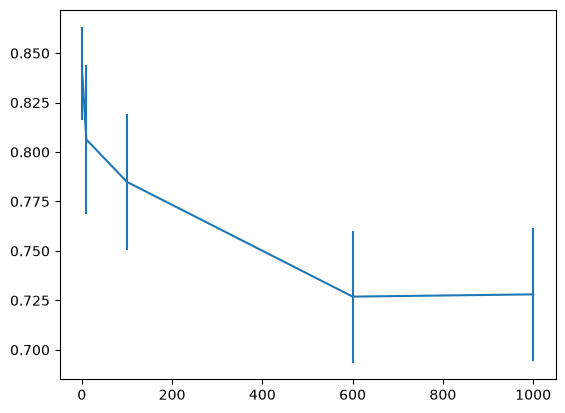

In [62]:
from xgboost import XGBClassifier
scale_pos_weight = [1,10,100,600,1000]

scores = {}
for n in scale_pos_weight:
    xgbc = XGBClassifier(eta=0.03, max_depth=6, min_child_weight=1, scale_pos_weight = n, random_state = 42)
    score = []
    for train_idx, val_idx in skf.split(X_full_train, y_full_train):
        X_train = scaler.fit_transform(X_full_train.iloc[train_idx])
        y_train = y_full_train.iloc[train_idx]

        X_val = scaler.transform(X_full_train.iloc[val_idx])
        y_val = y_full_train.iloc[val_idx]

        xgbc.fit(X_train, y_train)

        y_pred = xgbc.predict_proba(X_val)[:,1]

        pr = average_precision_score(y_val, y_pred)
        score.append(pr)
        print(n, '->', pr)
    scores[n] = (np.mean(score), np.std(score))

df_scores = pd.DataFrame(scores.values(), columns = ['mean', 'std'], index = scores.keys())

plt.errorbar(df_scores.index, df_scores['mean'], yerr=df_scores['std'])
plt.show()

In [63]:
df_scores

,mean,std
1,0.839849,0.023578
10,0.806371,0.037657
100,0.784890,0.034225
600,0.726898,0.033358
1000,0.728034,0.033570


In [64]:
max(df_scores['mean'])-min(df_scores['mean'])

0.1129515597834364

**note:** With this test we observe that just like for the random forest, this addition degraded the performance score, but in this case, the effect is important. The graph shows that the performance tends to decay with each increment of the parameter. The difference we see between the maximum value and minimum value is 0.113 which is ~3.4 times the deviation. Therefore, we determine that the negative effect of this parameter is clear and will continue the evaluation by using the model with the default value, which is 1.

## 7. Final model and evaluation

**note:** At this point of the exercise we have:
1. Scores:
Observing the scores, we see that the difference between both models is 0.001, which is much lower than the deviation, so it can be considered as noise.
RF: 0.841 +/-0.0343
XGB: 0.840+/-0.0236
   

2. Parameters:
RF: Trees = 100 - Max depth = 12 -> which means that there up to 4000 leaves per Tree
XGB: Trees = 100 - Max depth = 6 -> which means that there are approximately 64 leaves per Tree

3. Training cost:
We noticed that Random Forest had a slow training compared to the XGB classifier training. So, in production it would be more useful XGB.

4. Data drift: 
Shallow trees are able to capture more general patterns than the deep ones, which tend to memorize. In this specific task patterns change because attackers adapt themselves. Therefore, a model with a max_depth equal to 6 should degrade slower than a deep ensemble.

- conclusion: Based on the previous information we'll continue the evaluation with the XGB classifier. 

In [30]:
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import pickle

xgbc = XGBClassifier(eta=0.03, max_depth=6, min_child_weight=1, random_state = 42)
scaler = StandardScaler()

X_train_ = scaler.fit_transform(X_full_train)
X_test_ = scaler.transform(X_test)

xgbc.fit(X_train_, y_full_train)

y_pred = xgbc.predict_proba(X_test_)[:,1]

print(average_precision_score(y_test, y_pred))
pr_c = precision_recall_curve(y_test,y_pred)

0.8084548302680767


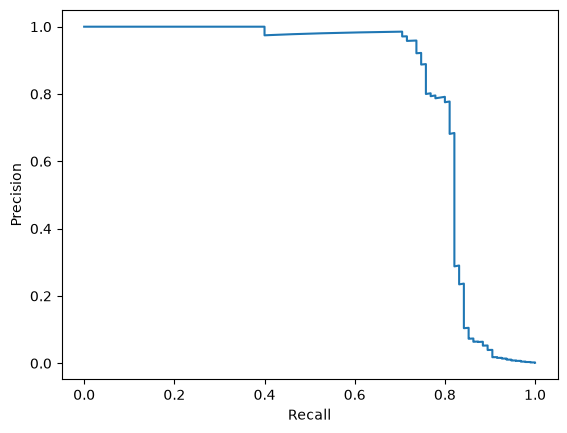

In [31]:
plt.plot(pr_c[1], pr_c[0])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

In [32]:
idx = np.argmin(abs(pr_c[1]-0.8))
print(idx)
print(pr_c[2][idx])
print('verification:', pr_c[0][idx], pr_c[1][idx])

32530
0.060319927
verification: 0.7755102040816326 0.8


In [33]:
print((y_pred>pr_c[2][idx]).sum(), '-', (y_test==1).sum())
print((y_pred<pr_c[2][idx]).sum(), '-', (y_test==0).sum())

97 - 95
56648 - 56651


In [34]:
from sklearn.metrics import confusion_matrix
y_pred_ = (y_pred>pr_c[2][idx])

print(confusion_matrix(y_test, y_pred_))

[[56630    21]
 [   19    76]]


**note**: Here we see that the final model (XGB classifier) was trained with the X_full_train and evaluated with X_test, this last one being new data that the model hasn't seen in any training. The average precision score we obtained from this is 0.808, which is 0.031 lower than the score we obtained in the cross-validation training (0.840 +/- 0.024) and is ~1.3 times the deviation. This behavior was expected, because using cross-validation adds an optimistic bias by construction, caused by choosing the configuration that worked best across the kfolds — and part of that "best" is favorable noise. So evaluating the model with data that is new to it gives us an unbiased metric. Additionally, we have to keep in mind that the test set contains only 95 positive cases, which makes the estimate noisy by itself. With this in mind, from the precision-recall curve we got the threshold at which the model reaches nearly 0.8 of recall, which was selected by considering how many frauds the model is going to catch and how many false alarms the system can tolerate. This threshold is 0.0603, which is much lower than the default threshold (0.5). Using a threshold of 0.0603 allows the model to achieve a precision of 0.776 and a recall of 0.800. The confusion matrix for this threshold shows us that:

TN = 56630
TP = 76
FP = 21
FN = 19

These metrics show us that the model correctly predicted 56630 normal transactions and 76 fraud transactions. Also, 21 normal transactions were predicted as fraud and 19 fraud transactions were predicted as normal.

Finally, we observed that the model went from a baseline where predictions were randomly classified and obtained a score of 0.00167, to a model that took brand new data and got a score of 0.808, which is 484 times the baseline score.

## 8. Conclusions

For this specific task, after evaluating 4 different models (Logistic Regression, Decision Tree, Random Forest and XGBoost), we identified that XGBoost was the one that came closest to what we were looking for. The model correctly predicted 76 frauds out of 95, leaving 21 false alarms. This model was chosen because its average precision in cross-validation was equivalent to the Random Forest's and, with no difference in performance, the deciding criterion became cost: the final XGBoost configuration had a lower maximum depth, which means cheaper training. Additionally, we tested parameters such as eta, which helped the model improve its score, and scale_pos_weight, a parameter that helps in cases of datasets with imbalanced classes, where we identified that the effect it had on the model was clearly significant and negative. Analyzing the precision-recall curve, we identified that the threshold that leaves us with a recall of approximately 0.8 is 0.0603, which is much lower than the default, resulting from a criterion of how many false alarms the business could tolerate.

It is important to mention two limitations of the model. First, the dataset features are PCA components, so the model cannot explain which characteristic of a transaction makes it suspicious, something that in a real case is needed to justify a block to an analyst or to the cardholder. Second, the 19 frauds the model did not detect are unlikely to be solved with more hyperparameter tuning: they probably require information the dataset does not contain, such as the cardholder's history, the device used, or the transaction's geolocation.

## 9. Saving parameters 

In [35]:
import pickle
#model, scaler and threshold save:
with open('fraud_model.bin', 'wb') as f:
    pickle.dump((xgbc, scaler, pr_c[2][idx], X_full_train.columns.tolist()),f)

## 10. Service test

In [ ]:
import numpy as np, json

raw_cols = ['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount']

pos = np.where(y_test.values == 1)[0][1]        
sample = X_test.iloc[pos][raw_cols].to_dict()
sample = {k: float(v) for k, v in sample.items()}  

print('Expected probability:', y_pred[pos])

with open('sample_fraud.json', 'w') as f:
    json.dump(sample, f, indent=2)

probabilidad esperada: 0.93013823


In [ ]:
import requests
r = requests.post('http://fraud-service-env.eba-jmeb3qga.us-east-1.elasticbeanstalk.com/predict', json=sample)
print(r.json())